In [2]:
import torch
import matplotlib.pyplot as plt

In [3]:
# 对称阵
A=torch.tensor([[3.0,1.0,2.0],
                [1.0,1.0,1.5],
                [2.0,1.5,5.0]])

# test A_T==A
A_T=A.T
diff:torch.Tensor=A_T-A
print(f"diff:{diff}")
print(f'max diff:{diff.max()}')

diff:tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
max diff:0.0


In [4]:
# 特征分解， eigen_vectors：column 是特征向量
eigen_values, eigen_vectors=torch.linalg.eig(A)

# print eigen vectors and eigen values
print("=============================")
print(f'eigen_values:{eigen_values}')
print("=============================")
print(f'eigen_vectors:{eigen_vectors}')

# restore test
E = eigen_vectors.real # 基向量矩阵，[e1,e2,e3,...,en]
L = torch.diag(eigen_values.real) # 特征值对角阵矩阵
print(f'E:{E}\nL:{L}')

M1=A@E
M2=E@L
diff=M1-M2
print("=============================")
print(f'diff:{diff}, max:{diff.max()}')

# A 分解
A_=E@L@E.T
diff=A_-A
print("=============================")
print(f'diff:{diff}, max:{diff.max()}')


eigen_values:tensor([6.7962+0.j, 1.7665+0.j, 0.4373+0.j])
eigen_vectors:tensor([[ 0.5051+0.j,  0.8410+0.j,  0.1938+0.j],
        [ 0.2969+0.j,  0.0415+0.j, -0.9540+0.j],
        [ 0.8104+0.j, -0.5394+0.j,  0.2287+0.j]])
E:tensor([[ 0.5051,  0.8410,  0.1938],
        [ 0.2969,  0.0415, -0.9540],
        [ 0.8104, -0.5394,  0.2287]])
L:tensor([[6.7962, 0.0000, 0.0000],
        [0.0000, 1.7665, 0.0000],
        [0.0000, 0.0000, 0.4373]])
diff:tensor([[-1.1921e-06, -3.5763e-07, -5.9605e-08],
        [ 0.0000e+00, -3.7998e-07, -5.9605e-08],
        [-4.7684e-07, -5.9605e-07, -2.9802e-07]]), max:0.0
diff:tensor([[ 7.1526e-07,  2.3842e-07,  7.1526e-07],
        [ 2.3842e-07, -1.7881e-07, -1.1921e-07],
        [ 7.1526e-07, -1.1921e-07,  4.7684e-07]]), max:7.152557373046875e-07


eigen_values:tensor([3.+0.j, 2.+0.j]), eigen_vetctors:tensor([[ 1.0000+0.j, -0.7071+0.j],
        [ 0.0000+0.j,  0.7071+0.j]])
y_trans:tensor([-0.7071,  0.7071]), y_eigen:tensor([-0.7071,  0.7071])


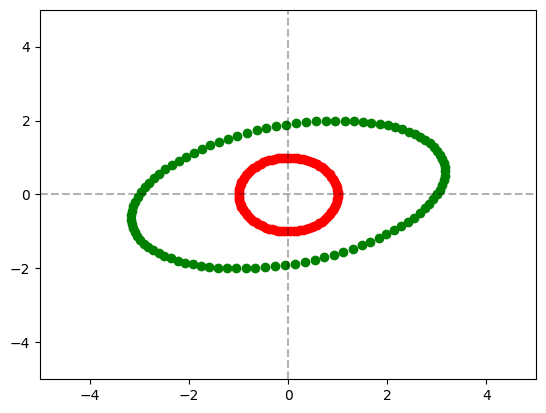

In [5]:
# practice 1 eigen value and eigen vector
A=torch.tensor([[3.0,1.0],
                [0.0,2.0]])

# eigen value, eigen_vector
eigen_values, eigen_vetctors=torch.linalg.eig(A)
print(f'eigen_values:{eigen_values}, eigen_vetctors:{eigen_vetctors}')

# test eigen vectors
eigen_v=eigen_vetctors[:,1].real # 第二列特征向量
y_trans=0.5*A@eigen_v
y_eigen=eigen_values[1].real*0.5*eigen_v
print(f'y_trans:{y_trans}, y_eigen:{y_eigen}')

# 标准圆形
N_POINTS=100
theta=torch.linspace(0,2*torch.pi,N_POINTS)
ux=torch.cos(theta)
uy=torch.sin(theta)
u_points=torch.column_stack([ux, uy])

# 变换
x_points=u_points@A.T

# plot
plt.scatter(u_points[:,0], u_points[:,1],c='r')
plt.scatter(x_points[:,0], x_points[:,1],c='g')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)

In [8]:
# practice 2， 协方差矩阵和它的逆
Σ=torch.tensor([[3.0,1.0],
                [0.0,2.0]])

# eigen value, eigen_vector
eigen_values, eigen_vectors=torch.linalg.eig(Σ)
print(f'eigen_values:{eigen_values}, eigen_vectors:{eigen_vectors}')

E=eigen_vectors.real
L=torch.diag(torch.square(eigen_values.real))
L_inv=torch.diag(1.0/torch.square(eigen_values.real))
E_inv=E.T

print(f'E.shape:{E.shape}, {E}, \nL.shape:{L.shape}, \n{L}, L_inv.shape:{L_inv.shape}, {L_inv},\n E_inv.shape:{E_inv.shape}')

M=E@L@E_inv
M_inv=E@L_inv@E_inv

y=M@M_inv
print(f'y:{y}')

eigen_values:tensor([3.+0.j, 2.+0.j]), eigen_vectors:tensor([[ 1.0000+0.j, -0.7071+0.j],
        [ 0.0000+0.j,  0.7071+0.j]])
E.shape:torch.Size([2, 2]), tensor([[ 1.0000, -0.7071],
        [ 0.0000,  0.7071]]), 
L.shape:torch.Size([2, 2]), 
tensor([[9., 0.],
        [0., 4.]]), L_inv.shape:torch.Size([2, 2]), tensor([[0.1111, 0.0000],
        [0.0000, 0.2500]]),
 E_inv.shape:torch.Size([2, 2])
y:tensor([[ 2.8472, -1.6250],
        [-0.7222,  0.5000]])


In [ ]:
import torch

A = torch.tensor([[4.0, 1.5, 0.8],
                  [1.5, 3.0, 1.2],
                  [0.8, 1.2, 2.0]])

# 1. 特征值分解
eigen_values, eigen_vectors = torch.linalg.eig(A)
eigen_values = eigen_values.real
eigen_vectors = eigen_vectors.real

# 1.1 按降序排序（确保 a ≥ b ≥ c）
sorted_indices = torch.argsort(eigen_values, descending=True)
eigen_values = eigen_values[sorted_indices]
eigen_vectors = eigen_vectors[:, sorted_indices]

# 2. 椭球半轴长度（长轴、中轴、短轴）
a_square, b_square, c_square = eigen_values
a, b, c = torch.sqrt(a_square), torch.sqrt(b_square), torch.sqrt(c_square)
print(f'半轴长度 -> a: {a:.4f}, b: {b:.4f}, c: {c:.4f}')

# 3. 分解
E = eigen_vectors
Lambda = torch.diag(eigen_values)
Lambda_inv = torch.diag(1.0 / eigen_values)
E_T = E.T

# 4. 协方差矩阵的逆
M_inv = E @ Lambda_inv @ E_T
print(f'M_inv:\n{M_inv}')
print(f'直接求逆验证:\n{torch.linalg.inv(A)}')

# 5. 马氏距离的平方（二次型）
d = torch.tensor([1.0, 2.0, 3.0])
quadratic_form = d @ M_inv @ d   # 等价于 d.T @ M_inv @ d，结果都是标量
mahalanobis_distance = torch.sqrt(quadratic_form)
print(f'马氏距离: {mahalanobis_distance:.4f}')
print(f'马氏距离平方 (d^T Σ^{{-1}} d): {quadratic_form:.4f}')

# 6. 3DGS 高斯值
_3_dgs = torch.exp(-0.5 * quadratic_form)  # ✅ 正确
print(f'3dgs: {_3_dgs:.4f}')

半轴长度 -> a: 2.3660, b: 1.4893, c: 1.0881
M_inv:
tensor([[ 0.3102, -0.1388, -0.0408],
        [-0.1388,  0.5007, -0.2449],
        [-0.0408, -0.2449,  0.6633]])
直接求逆验证:
tensor([[ 0.3102, -0.1388, -0.0408],
        [-0.1388,  0.5007, -0.2449],
        [-0.0408, -0.2449,  0.6633]])
马氏距离: 2.1316
马氏距离平方 (d^T Σ^{-1} d): 4.5435
3dgs: 0.1031


半轴长度 -> a: 2.3660, b: 1.4893, c: 1.0881
中心: tensor([0., 0., 0.])
sphere surface poitns (k=1.0, axis1): tensor([1.7225, 1.3847, 0.8448])
sphere surface poitns (k=1.0, axis2): tensor([ 1.0109, -0.8078, -0.7372])
sphere surface poitns (k=1.0, axis3): tensor([ 0.1045, -0.6558,  0.8619])


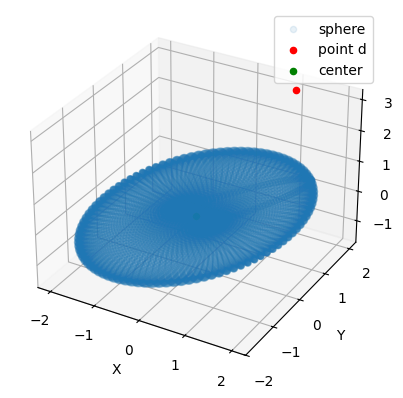

In [ ]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 假设已有 A, eigen_values, eigen_vectors, a, b, c
A = torch.tensor([[4.0, 1.5, 0.8],
                  [1.5, 3.0, 1.2],
                  [0.8, 1.2, 2.0]])

# 1. 特征值分解
eigen_values, eigen_vectors = torch.linalg.eig(A)
eigen_values = eigen_values.real
eigen_vectors = eigen_vectors.real

# 1.1 按降序排序（确保 a ≥ b ≥ c）
sorted_indices = torch.argsort(eigen_values, descending=True)
eigen_values = eigen_values[sorted_indices]
eigen_vectors = eigen_vectors[:, sorted_indices]

# 2. 椭球半轴长度（长轴、中轴、短轴）
a_square, b_square, c_square = eigen_values
a, b, c = torch.sqrt(a_square), torch.sqrt(b_square), torch.sqrt(c_square)
print(f'半轴长度 -> a: {a:.4f}, b: {b:.4f}, c: {c:.4f}')

# 中心
center = torch.tensor([0.0, 0.0, 0.0])
print(f'中心: {center}')

# 椭球表面上的点（示例：k=1，沿主轴方向）
k = 1.0
surface_points = []
for i in range(3):
    direction = eigen_vectors[:, i]  # 特征向量方向
    point = k * torch.sqrt(eigen_values[i]) * direction  # 椭球表面点
    surface_points.append(point)
    print(f'sphere surface poitns (k={k}, axis{i+1}): {point}')

# 可视化（3D椭球）
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制椭球（近似）
u = torch.linspace(0, 2 * torch.pi, 100)
v = torch.linspace(0, torch.pi, 100)
x = a * torch.outer(torch.cos(u), torch.sin(v))
y = b * torch.outer(torch.sin(u), torch.sin(v))
z = c * torch.outer(torch.ones_like(u), torch.cos(v))

# 变换到特征向量基
ellipsoid_points = eigen_vectors @ torch.stack([x.flatten(), y.flatten(), z.flatten()])
ax.scatter(ellipsoid_points[0], ellipsoid_points[1], ellipsoid_points[2], alpha=0.1, label='sphere')

# 绘制点 d
ax.scatter(d[0], d[1], d[2], color='red', label='point d')
ax.scatter(center[0], center[1], center[2], color='green', label='center')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [9]:
import torch

torch.manual_seed(42)
cov = torch.tensor([[10, 5], [5, 3]], dtype=torch.float32)
points = torch.randn(1000, 2) @ cov.T

# Step 1: 中心化
centered = points - torch.mean(points, axis=0)

# Step 2: 协方差矩阵
Sigma = centered.T @ centered / (len(points) - 1)

# Step 3: 特征分解
eigenvalues, eigenvectors = torch.linalg.eigh(Sigma)
sort_idx = torch.argsort(eigenvalues, descending=True)
principal_axis = eigenvectors[:, sort_idx[0]]

# Step 4: 验证（用中心化数据投影）
projected = centered @ principal_axis

print(f"主成分贡献：{eigenvalues[sort_idx[0]]/torch.sum(eigenvalues)*100:.1f}%")

主成分贡献：99.9%


In [ ]:
# PCA 主成分分析实战
import torch

torch.manual_seed(42)
mu=torch.tensor([7.0,1.0])
covariance=torch.tensor([
    [10.0, 5.0],
    [5.0, 3.0]
])
distributions=torch.distributions.MultivariateNormal(loc=mu, covariance_matrix=covariance)
points=distributions.sample((100,))
points_mean=torch.mean(points, dim=0)
print(f"points shape:{points.shape}, points mean:{points_mean}")

# build covariance matrix
centered=points-points_mean
centered_T=centered.T
cov=centered_T@centered/(len(points)-1)
print(f"covariance matrix:\n{cov}")

# eigen decomposition
eigen_values, eigen_vectors=torch.linalg.eig(cov)
eigen_values=eigen_values.real
eigen_vectors=eigen_vectors.real
print(f"eigen values:{eigen_values}, eigen vectors:\n{eigen_vectors}")

# sort by eigen values
sorted_idxes=torch.argsort(eigen_values, descending=True)
eigen_values=eigen_values[sorted_idxes]
eigen_vectors=eigen_vectors[:, sorted_idxes]
print(f"sorted eigen values:{eigen_values}, sorted eigen vectors:\n{eigen_vectors}")
print(f'半轴:a: {torch.sqrt(eigen_values[0]):.4f}, b: {torch.sqrt(eigen_values[1]):.4f}')
print(f"主成分贡献：{eigen_values[0]/torch.sum(eigen_values)*100:.1f}%")

points shape:torch.Size([100, 2]), points mean:tensor([6.5157, 0.9311])
covariance matrix:
tensor([[10.6522,  5.5590],
        [ 5.5590,  3.2934]])
eigen values:tensor([13.6392,  0.3064]), eigen vectors:
tensor([[ 0.8809, -0.4733],
        [ 0.4733,  0.8809]])
sorted eigen values:tensor([13.6392,  0.3064]), sorted eigen vectors:
tensor([[ 0.8809, -0.4733],
        [ 0.4733,  0.8809]])
半轴:a: 3.6931, b: 0.5535
